In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
import json
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV

d:\Project\machine-learning\venv_timeseries\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv('train.csv')
data_store = pd.read_csv('store.csv')
data.head(5)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17020\2320805515.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [123]:
data['Sales'].value_counts(normalize=True)
data.shape

(1017209, 9)

In [124]:
data_store.head(5)
data_store.shape

(1115, 10)

In [3]:
merge_data = data.merge(data_store, on='Store', how = 'left')
merge_data.shape

(1017209, 18)

In [126]:
merge_data.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [127]:
merge_data['Promo2'].value_counts()

Promo2
1    509178
0    508031
Name: count, dtype: int64

In [4]:
merge_data['competition_open_since_unknown'] = merge_data['CompetitionOpenSinceMonth'].isnull().astype(int)

In [5]:
merge_data['CompetitionOpenSinceYear'] = merge_data['CompetitionOpenSinceYear'].fillna(2060)
merge_data['CompetitionOpenSinceMonth'] = merge_data['CompetitionOpenSinceMonth'].fillna(1)

In [6]:
merge_data['Promo2SinceWeek'] = merge_data['Promo2SinceWeek'].fillna(0)
merge_data['Promo2SinceYear'] = merge_data['Promo2SinceYear'].fillna(0)
merge_data['PromoInterval'] = merge_data['PromoInterval'].fillna('')

In [131]:
merge_data.isnull().sum()

Store                                0
DayOfWeek                            0
Date                                 0
Sales                                0
Customers                            0
Open                                 0
Promo                                0
StateHoliday                         0
SchoolHoliday                        0
StoreType                            0
Assortment                           0
CompetitionDistance               2642
CompetitionOpenSinceMonth            0
CompetitionOpenSinceYear             0
Promo2                               0
Promo2SinceWeek                      0
Promo2SinceYear                      0
PromoInterval                        0
competition_open_since_unknown       0
dtype: int64

In [7]:
merge_data['competition_open_since_unknown'].value_counts().sort_index(ascending=False).head(10)

competition_open_since_unknown
1    323348
0    693861
Name: count, dtype: int64

In [8]:
merge_data['competition_distance_missing'] = merge_data['CompetitionDistance'].isnull().astype(int)
merge_data['CompetitionDistance'] = merge_data['CompetitionDistance'].fillna(merge_data['CompetitionDistance'].median())

In [9]:
merge_data['competition_distance_missing'].value_counts()

competition_distance_missing
0    1014567
1       2642
Name: count, dtype: int64

In [135]:
merge_data['Date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [10]:
merge_data["Date"] = pd.to_datetime(merge_data['Date'])
merge_data['Date'].dtype

dtype('<M8[us]')

In [11]:
merge_data['Month'] = merge_data['Date'].dt.month
merge_data[['Date', 'Month']].head(4)

,Date,Month
0,2015-07-31,7
1,2015-07-31,7
2,2015-07-31,7
3,2015-07-31,7


In [12]:
merge_data['PromoInterval'].unique()

<StringArray>
['', 'Jan,Apr,Jul,Oct', 'Feb,May,Aug,Nov', 'Mar,Jun,Sept,Dec']
Length: 4, dtype: str

In [13]:
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sept', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

merge_data['Month_abbr'] = merge_data['Month'].map(month_map)

In [14]:
merge_data['is_promo2_active_month'] = merge_data.apply(
    lambda row: row['Month_abbr'] in row['PromoInterval'].split(','), axis=1
)

In [15]:
merge_data[['Month_abbr', 'PromoInterval', 'is_promo2_active_month']].sample(10)

,Month_abbr,PromoInterval,is_promo2_active_month
908791,Apr,"Jan,Apr,Jul,Oct",True
47945,Jun,,False
19751,Jul,"Jan,Apr,Jul,Oct",True
502689,Apr,,False
903,Jul,"Jan,Apr,Jul,Oct",True
353289,Aug,"Feb,May,Aug,Nov",True
668252,Nov,,False
441691,Jun,"Jan,Apr,Jul,Oct",False
270738,Nov,"Mar,Jun,Sept,Dec",False
810963,Jul,,False


In [142]:
merge_data[merge_data['is_promo2_active_month'] == True][['Month_abbr', 'PromoInterval', 'is_promo2_active_month']].sample(10)

,Month_abbr,PromoInterval,is_promo2_active_month
1005497,Jan,"Jan,Apr,Jul,Oct",True
306676,Oct,"Jan,Apr,Jul,Oct",True
888391,Apr,"Jan,Apr,Jul,Oct",True
480279,Apr,"Jan,Apr,Jul,Oct",True
739056,Sept,"Mar,Jun,Sept,Dec",True
840775,Jun,"Mar,Jun,Sept,Dec",True
904687,Apr,"Jan,Apr,Jul,Oct",True
157843,Mar,"Mar,Jun,Sept,Dec",True
893707,Apr,"Jan,Apr,Jul,Oct",True
770607,Aug,"Feb,May,Aug,Nov",True


In [143]:
merge_data['is_promo2_active_month'].value_counts()

is_promo2_active_month
False    842417
True     174792
Name: count, dtype: int64

In [16]:
merge_data['Year'] = merge_data['Date'].dt.year
merge_data['competition_open_months'] = (merge_data['Year'] - merge_data['CompetitionOpenSinceYear']) * 12 + (merge_data['Month'] - merge_data['CompetitionOpenSinceMonth'])
merge_data[['Date', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 'competition_open_months']].sample(10)

,Date,CompetitionOpenSinceYear,CompetitionOpenSinceMonth,competition_open_months
667786,2013-11-10,2060.0,1.0,-554.0
703401,2013-10-09,2060.0,1.0,-555.0
810796,2013-07-05,2005.0,9.0,94.0
837918,2013-06-10,2060.0,1.0,-559.0
298005,2014-10-27,2060.0,1.0,-543.0
358862,2014-08-23,2060.0,1.0,-545.0
687164,2013-10-24,2010.0,9.0,37.0
602299,2014-01-08,2007.0,5.0,80.0
19933,2015-07-14,2005.0,11.0,116.0
122846,2015-04-12,2015.0,3.0,1.0


In [17]:
merge_data = merge_data.sort_values(['Store', 'Date']).reset_index(drop=True)

In [146]:
merge_data.groupby('Store').head(3)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceWeek,Promo2SinceYear,PromoInterval,competition_open_since_unknown,competition_distance_missing,Month,Month_abbr,is_promo2_active_month,Year,competition_open_months
0,1,2,2013-01-01,0,0,0,0,a,1,c,...,0.0,0.0,,0,0,1,Jan,False,2013,52.0
1,1,3,2013-01-02,5530,668,1,0,0,1,c,...,0.0,0.0,,0,0,1,Jan,False,2013,52.0
2,1,4,2013-01-03,4327,578,1,0,0,1,c,...,0.0,0.0,,0,0,1,Jan,False,2013,52.0
942,2,2,2013-01-01,0,0,0,0,a,1,a,...,13.0,2010.0,"Jan,Apr,Jul,Oct",0,0,1,Jan,True,2013,62.0
943,2,3,2013-01-02,4422,650,1,0,0,1,a,...,13.0,2010.0,"Jan,Apr,Jul,Oct",0,0,1,Jan,True,2013,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015326,1114,3,2013-01-02,20642,3401,1,0,0,1,a,...,0.0,0.0,,1,0,1,Jan,False,2013,-564.0
1015327,1114,4,2013-01-03,18463,3211,1,0,0,1,a,...,0.0,0.0,,1,0,1,Jan,False,2013,-564.0
1016267,1115,2,2013-01-01,0,0,0,0,a,1,d,...,22.0,2012.0,"Mar,Jun,Sept,Dec",1,0,1,Jan,False,2013,-564.0
1016268,1115,3,2013-01-02,3697,305,1,0,0,1,d,...,22.0,2012.0,"Mar,Jun,Sept,Dec",1,0,1,Jan,False,2013,-564.0


In [18]:
merge_data['Sales_lag_1'] = merge_data.groupby('Store')['Sales'].shift(1)
merge_data['Sales_lag_7'] = merge_data.groupby('Store')['Sales'].shift(7)
merge_data['Sales_lag_14'] = merge_data.groupby('Store')['Sales'].shift(14)

In [19]:
merge_data['Sales_roll_mean_7'] = merge_data.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).mean())
merge_data['Sales_roll_std_7'] = merge_data.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).std())

In [149]:
merge_data[['Store', 'Date', 'Sales', 'Sales_lag_1', 'Sales_lag_7', 'Sales_roll_mean_7']].groupby('Store').head(15)

,Store,Date,Sales,Sales_lag_1,Sales_lag_7,Sales_roll_mean_7
0,1,2013-01-01,0,NaN,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN,NaN
2,1,2013-01-03,4327,5530.0,NaN,NaN
3,1,2013-01-04,4486,4327.0,NaN,NaN
4,1,2013-01-05,4997,4486.0,NaN,NaN
...,...,...,...,...,...,...
1016277,1115,2013-01-11,5142,5007.0,4540.0,4445.000000
1016278,1115,2013-01-12,4497,5142.0,4771.0,4531.000000
1016279,1115,2013-01-13,0,4497.0,0.0,4491.857143
1016280,1115,2013-01-14,3158,0.0,6905.0,4491.857143


In [150]:
merge_data['Open'].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [20]:
df_model = merge_data[merge_data['Open'] == 1].copy()

In [152]:
print(merge_data.shape)
print(df_model.shape)

(1017209, 30)
(844392, 30)


In [21]:
df_model[['Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_roll_mean_7', 'Sales_roll_std_7']].isnull().sum()

Sales_lag_1             18
Sales_lag_7           5578
Sales_lag_14         12226
Sales_roll_mean_7     5578
Sales_roll_std_7      5578
dtype: int64

In [22]:
df_model = df_model.dropna(subset=['Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_roll_mean_7', 'Sales_roll_std_7'])
print(df_model.shape)

(832166, 30)


In [23]:
df_model['IsWeekend'] = df_model['DayOfWeek'].isin([6, 7]).astype(int)
df_model['WeekOfYear'] = df_model['Date'].dt.isocalendar().week

In [156]:
df_model.dtypes

Store                                      int64
DayOfWeek                                  int64
Date                              datetime64[us]
Sales                                      int64
Customers                                  int64
Open                                       int64
Promo                                      int64
StateHoliday                              object
SchoolHoliday                              int64
StoreType                                    str
Assortment                                   str
CompetitionDistance                      float64
CompetitionOpenSinceMonth                float64
CompetitionOpenSinceYear                 float64
Promo2                                     int64
Promo2SinceWeek                          float64
Promo2SinceYear                          float64
PromoInterval                                str
competition_open_since_unknown             int64
competition_distance_missing               int64
Month               

In [24]:
cat_cols = ['StateHoliday', 'StoreType', 'Assortment']
for col in cat_cols:
    df_model[col] = df_model[col].astype('category')

In [25]:
df_model = df_model.drop(columns=['Customers', 'Month_abbr', 'PromoInterval'])

In [159]:
print(df_model['Date'].min(), df_model['Date'].max())

2013-01-15 00:00:00 2015-07-31 00:00:00


In [26]:
cutoff_date = '2015-06-19'

train = df_model[df_model['Date'] < cutoff_date]
test = df_model[df_model['Date'] >= cutoff_date]

print(train.shape, test.shape)
print("Train date range:", train['Date'].min(), "-", train['Date'].max())
print("Test date range:", test['Date'].min(), "-", test['Date'].max())

(790770, 29) (41396, 29)
Train date range: 2013-01-15 00:00:00 - 2015-06-18 00:00:00
Test date range: 2015-06-19 00:00:00 - 2015-07-31 00:00:00


In [27]:
train['StateHoliday'] = train['StateHoliday'].astype(str)
test['StateHoliday'] = test['StateHoliday'].astype(str)

In [28]:
cat_cols = ['Store', 'StateHoliday', 'StoreType', 'Assortment']
for col in cat_cols:
    train[col] = train[col].astype(object).astype('category')
    test[col] = test[col].astype(object).astype('category')

In [29]:
for col in cat_cols:
    all_cats = pd.api.types.union_categoricals([train[col], test[col]]).categories
    train[col] = train[col].cat.set_categories(all_cats)
    test[col] = test[col].cat.set_categories(all_cats)

In [30]:
drop_cols = ['Sales', 'Date', 'Open']
X_train = train.drop(columns=drop_cols)
X_test = test.drop(columns=drop_cols)

In [31]:
y_train_log = np.log1p(train['Sales'])
y_test_log = np.log1p(test['Sales'])

In [32]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train_log = y_train_log.reset_index(drop=True)
y_test_log = y_test_log.reset_index(drop=True)

print(X_train.shape, X_test.shape)
print(X_train.dtypes)

(790770, 26) (41396, 26)
Store                             category
DayOfWeek                            int64
Promo                                int64
StateHoliday                      category
SchoolHoliday                        int64
StoreType                         category
Assortment                        category
CompetitionDistance                float64
CompetitionOpenSinceMonth          float64
CompetitionOpenSinceYear           float64
Promo2                               int64
Promo2SinceWeek                    float64
Promo2SinceYear                    float64
competition_open_since_unknown       int64
competition_distance_missing         int64
Month                                int32
is_promo2_active_month                bool
Year                                 int32
competition_open_months            float64
Sales_lag_1                        float64
Sales_lag_7                        float64
Sales_lag_14                       float64
Sales_roll_mean_7            

In [33]:
X_train['WeekOfYear'] = X_train['WeekOfYear'].astype('int32')
X_test['WeekOfYear'] = X_test['WeekOfYear'].astype('int32')

In [36]:
X_train['WeekOfYear'] = X_train['WeekOfYear'].astype('int32')
X_test['WeekOfYear'] = X_test['WeekOfYear'].astype('int32')

model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model.fit(
    X_train, y_train_log,
    categorical_feature=['Store', 'StateHoliday', 'StoreType', 'Assortment']
)
print("Training berhasil!")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 790770, number of used features: 26
[LightGBM] [Info] Start training from score 8.757344
Training berhasil!


In [37]:
y_pred_log = model.predict(X_test)
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

In [38]:
def rmspe(y_true, y_pred):
    mask = y_true != 0  # hindari pembagian oleh nol
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

score = rmspe(y_test_actual.values, y_pred_actual)
print(f"RMSPE: {score:.4f}")

RMSPE: 0.1148


In [39]:
#Feature importance bawaan LightGBM 
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(15))

                feature  importance
0                 Store        4661
1             DayOfWeek        1906
25           WeekOfYear        1613
21         Sales_lag_14        1212
19          Sales_lag_1        1018
22    Sales_roll_mean_7         895
20          Sales_lag_7         830
2                 Promo         648
23     Sales_roll_std_7         637
17                 Year         384
15                Month         383
3          StateHoliday         183
7   CompetitionDistance         154
4         SchoolHoliday         128
5             StoreType         107


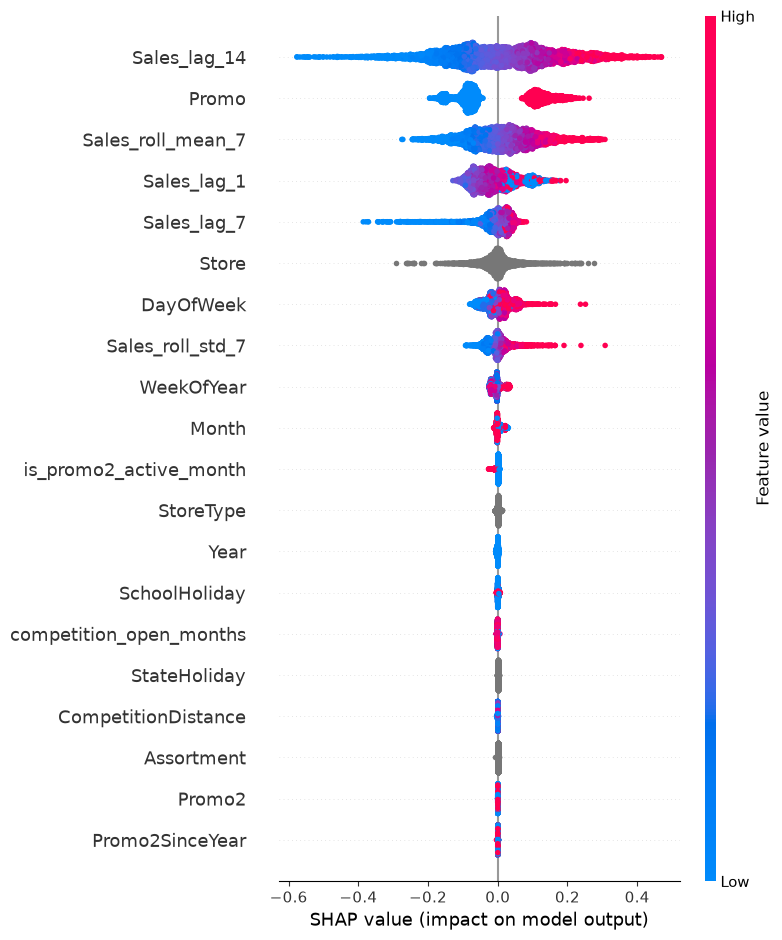

In [40]:
# Sample buat efisiensi komputasi
X_sample = X_test.sample(n=5000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

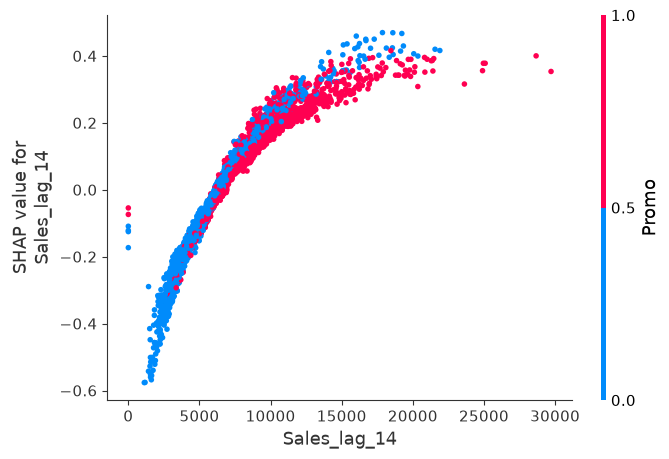

In [177]:
shap.dependence_plot('Sales_lag_14', shap_values, X_sample)

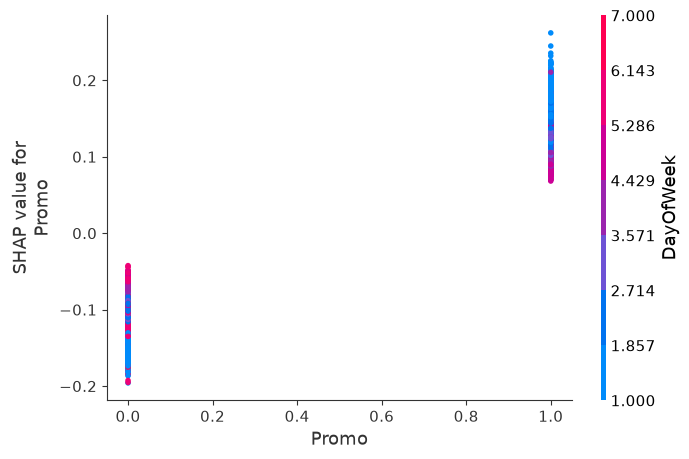

In [178]:
shap.dependence_plot('Promo', shap_values, X_sample)

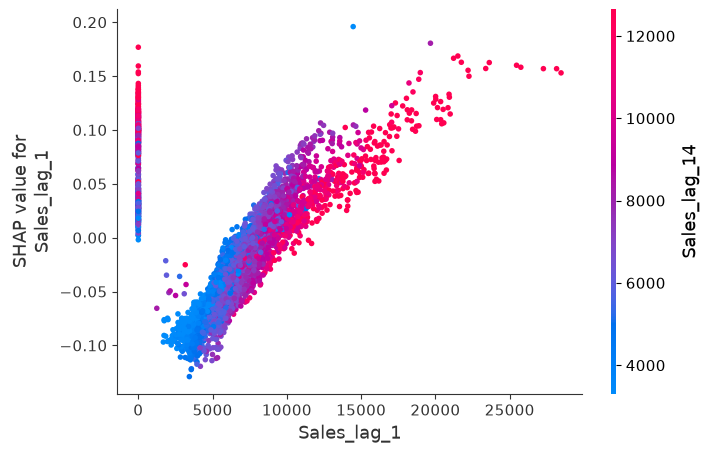

In [179]:
shap.dependence_plot('Sales_lag_1', shap_values, X_sample)

In [41]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'num_leaves': [31, 50, 70, 100],
    'max_depth': [5, 7, 10, -1],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 800],
    'min_child_samples': [10, 20, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

lgb_model = lgb.LGBMRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)


In [42]:
random_search.fit(
    X_train, y_train_log,
    categorical_feature=['Store', 'StateHoliday', 'StoreType', 'Assortment']
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 790770, number of used features: 26
[LightGBM] [Info] Start training from score 8.757344


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [5, 7, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a b

In [43]:
print("Best params:", random_search.best_params_)
print("Best CV score (neg RMSE, log scale):", random_search.best_score_)

Best params: {'subsample': 0.9, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV score (neg RMSE, log scale): -0.1710138204702249


In [44]:
best_model = random_search.best_estimator_

y_pred_log_tuned = best_model.predict(X_test)
y_pred_actual_tuned = np.expm1(y_pred_log_tuned)

score_tuned = rmspe(y_test_actual.values, y_pred_actual_tuned)
print(f"RMSPE (tuned model): {score_tuned:.4f}")
print(f"RMSPE (baseline model): 0.1148")

RMSPE (tuned model): 0.1213
RMSPE (baseline model): 0.1148


In [45]:
from sklearn.metrics import make_scorer

def rmspe_log_scorer(y_true_log, y_pred_log):
    y_true = np.expm1(np.asarray(y_true_log))
    y_pred = np.expm1(np.asarray(y_pred_log))
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

rmspe_scorer = make_scorer(rmspe_log_scorer, greater_is_better=False)

In [46]:
random_search_rmspe = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring=rmspe_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_rmspe.fit(
    X_train, y_train_log,
    categorical_feature=['Store', 'StateHoliday', 'StoreType', 'Assortment']
)

print("Best params (RMSPE-optimized):", random_search_rmspe.best_params_)
print("Best CV RMSPE:", -random_search_rmspe.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053720 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 790770, number of used features: 26
[LightGBM] [Info] Start training from score 8.757344
Best params (RMSPE-optimized): {'subsample': 0.8, 'num_leaves': 70, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV RMSPE: 0.23976284916444862


In [47]:
best_model_rmspe = random_search_rmspe.best_estimator_

y_pred_log_v2 = best_model_rmspe.predict(X_test)
y_pred_actual_v2 = np.expm1(y_pred_log_v2)

score_v2 = rmspe(y_test_actual.values, y_pred_actual_v2)
print(f"RMSPE (tuned dgn custom scorer): {score_v2:.4f}")
print(f"RMSPE (tuned dgn RMSE scorer):   0.1213")
print(f"RMSPE (baseline default):        0.1148")

RMSPE (tuned dgn custom scorer): 0.1138
RMSPE (tuned dgn RMSE scorer):   0.1213
RMSPE (baseline default):        0.1148


In [48]:
df_model[['Date', 'DayOfWeek']].head(10)

,Date,DayOfWeek
14,2013-01-15,2
15,2013-01-16,3
16,2013-01-17,4
17,2013-01-18,5
18,2013-01-19,6
20,2013-01-21,1
21,2013-01-22,2
22,2013-01-23,3
23,2013-01-24,4
24,2013-01-25,5


In [49]:
df_model['IsWeekend'] = df_model['DayOfWeek'].isin([6, 7]).astype(int)

In [55]:
# 1. Kategori persis seperti X_train saat training
categories = {
    'Store': X_train['Store'].cat.categories.tolist(),
    'StateHoliday': X_train['StateHoliday'].cat.categories.tolist(),
    'StoreType': X_train['StoreType'].cat.categories.tolist(),
    'Assortment': X_train['Assortment'].cat.categories.tolist(),
}

# 2. Store metadata statis (1 baris per toko) - subset kolom yang dibutuhkan wrapper.
#    Ambil dari df_model (sebelum di-drop kolom Customers/Open/dll), unik per Store.
store_meta_cols = [
    'Store', 'StoreType', 'Assortment', 'CompetitionDistance',
    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
    'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval',
    'competition_open_since_unknown', 'competition_distance_missing'
]
store_meta = merge_data[store_meta_cols].drop_duplicates(subset='Store').reset_index(drop=True)

assert store_meta['Store'].is_unique, (
    "store_meta punya duplikat Store - berarti ada kolom yang ternyata BUKAN statis. "
    "Cek ulang store_meta_cols di atas."
)

# 3. Bundle semuanya
joblib.dump({
    'model': best_model_rmspe,
    'store_meta': store_meta,
    'categories': categories
}, 'rossmann_model_bundle.pkl')

print("Bundle tersimpan: rossmann_model_bundle.pkl")
print("Jumlah toko di store_meta:", store_meta.shape[0])

Bundle tersimpan: rossmann_model_bundle.pkl
Jumlah toko di store_meta: 1115


In [54]:
'PromoInterval' in merge_data.columns

True

In [61]:
from rossmann_predictor import RossmannSalesPredictor

predictor = RossmannSalesPredictor.load('rossmann_model_bundle.pkl')

# contoh histori 14 hari terakhir untuk Store 1
history = df_model[(df_model['Store'] == 1) & (df_model['Date'] < '2015-06-19')].tail(14)[['Date', 'Sales']]

pred = predictor.predict(
    store_id=1,
    target_date='2015-06-19',
    history_df=history,
    promo=1,
    state_holiday='0',
    school_holiday=0
)
print(f"Prediksi Sales: {pred:.0f}")

Prediksi Sales: 5024


In [62]:
actual = df_model[(df_model['Store'] == 1) & (df_model['Date'] == '2015-06-19')]['Sales'].values
print("Actual Sales:", actual)
print("Predicted Sales:", 5024)

Actual Sales: [4202]
Predicted Sales: 5024


In [63]:
test_cases = [
    {'store_id': 1, 'target_date': '2015-06-19'},
    {'store_id': 85, 'target_date': '2015-06-25'},
    {'store_id': 500, 'target_date': '2015-07-01'},
]

for case in test_cases:
    history = df_model[
        (df_model['Store'] == case['store_id']) &
        (df_model['Date'] < case['target_date'])
    ].tail(14)[['Date', 'Sales']]

    row_actual = df_model[
        (df_model['Store'] == case['store_id']) &
        (df_model['Date'] == case['target_date'])
    ]

    if row_actual.empty or len(history) < 14:
        print(f"Store {case['store_id']}: data tidak lengkap, skip")
        continue

    pred = predictor.predict(
        store_id=case['store_id'],
        target_date=case['target_date'],
        history_df=history,
        promo=int(row_actual['Promo'].values[0]),
        state_holiday=str(row_actual['StateHoliday'].values[0]),
        school_holiday=int(row_actual['SchoolHoliday'].values[0])
    )
    actual = row_actual['Sales'].values[0]
    error_pct = abs(pred - actual) / actual * 100

    print(f"Store {case['store_id']} ({case['target_date']}): predicted={pred:.0f}, actual={actual}, error={error_pct:.1f}%")

Store 1 (2015-06-19): predicted=5024, actual=4202, error=19.6%
Store 85 (2015-06-25): predicted=5755, actual=5968, error=3.6%
Store 500 (2015-07-01): predicted=7398, actual=6084, error=21.6%


In [64]:
for case in test_cases:
    hist_check = merge_data[
        (merge_data['Store'] == case['store_id']) &
        (merge_data['Date'] < case['target_date'])
    ].tail(14)
    n_closed = (hist_check['Open'] == 0).sum()
    print(f"Store {case['store_id']}: {n_closed} hari tutup di 14 hari terakhir")

Store 1: 2 hari tutup di 14 hari terakhir
Store 85: 0 hari tutup di 14 hari terakhir
Store 500: 2 hari tutup di 14 hari terakhir


In [66]:
import importlib
import rossmann_predictor
importlib.reload(rossmann_predictor)
from rossmann_predictor import RossmannSalesPredictor

predictor = RossmannSalesPredictor.load('rossmann_model_bundle.pkl')

for case in test_cases:
    history =merge_data[
        (merge_data['Store'] == case['store_id']) &
        (merge_data['Date'] < case['target_date'])
    ].tail(14)[['Date', 'Sales']]

    row_actual = df_model[
        (df_model['Store'] == case['store_id']) &
        (df_model['Date'] == case['target_date'])
    ]

    if row_actual.empty or len(history) < 14:
        print(f"Store {case['store_id']}: data tidak lengkap, skip")
        continue

    pred = predictor.predict(
        store_id=case['store_id'],
        target_date=case['target_date'],
        history_df=history,
        promo=int(row_actual['Promo'].values[0]),
        state_holiday=str(row_actual['StateHoliday'].values[0]),
        school_holiday=int(row_actual['SchoolHoliday'].values[0])
    )
    actual = row_actual['Sales'].values[0]
    error_pct = abs(pred - actual) / actual * 100
    print(f"Store {case['store_id']} ({case['target_date']}): predicted={pred:.0f}, actual={actual}, error={error_pct:.1f}%")

Store 1 (2015-06-19): predicted=4827, actual=4202, error=14.9%
Store 85 (2015-06-25): predicted=5755, actual=5968, error=3.6%
Store 500 (2015-07-01): predicted=7027, actual=6084, error=15.5%
